In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    roc_auc_score,
    precision_score,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("../Data/preprocessed.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Average,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,29.850000,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,55.573529,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,54.075000,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,40.905556,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,75.825000,1,0,0,1,0


In [3]:
x = df.drop(['Churn'], axis=1)
y = df['Churn']                              

In [4]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y,
    test_size=0.2, 
    random_state=42,                                                                     
    stratify=y
)

In [5]:
xtrain_no_scale = xtrain.copy()
ytrain_no_scale = ytrain.copy()

In [6]:
smote = SMOTE(random_state=42)
xtrain_no_scale_res, ytrain_no_scale_res = smote.fit_resample(xtrain_no_scale, ytrain_no_scale)

# Applying without Scalling

In [7]:
algorithms = {
    "LogisticRegression": LogisticRegression(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42, eval_metric='logloss'),
    "GaussianNB": GaussianNB()
}

In [42]:
result_list = []

for model_name, model in algorithms.items():
    model.fit(xtrain_no_scale_res, ytrain_no_scale_res)
    pred = model.predict(xtest)
    pred_proba = model.predict_proba(xtest)[:, 1]
    
    result_list.append({
        'Model': model_name,
        'Train Score': model.score(xtrain_no_scale_res, ytrain_no_scale_res),
        'Test Score': model.score(xtest, ytest),
        'Accuracy Score': accuracy_score(ytest, pred),
        'Recall Score': recall_score(ytest, pred),
        'Precision Score': precision_score(ytest, pred),
        'F1 Score': f1_score(ytest, pred),
        'Roc Auc Score': roc_auc_score(ytest, pred_proba),
        'Confussion Matrix': confusion_matrix(ytest, pred)

    })

results = pd.DataFrame(result_list)

In [43]:
print("Result without scaling:")
results.sort_values(by='Roc Auc Score', ascending=False)

Result without scaling:


,Model,Train Score,Test Score,Accuracy Score,Recall Score,Precision Score,F1 Score,Roc Auc Score,Confussion Matrix
2,RandomForestClassifier,0.999153,0.778962,0.778962,0.625668,0.577778,0.600770,0.812731,"[[862, 171], [140, 234]]"
3,XGBClassifier,0.963075,0.765458,0.765458,0.593583,0.555000,0.573643,0.810894,"[[855, 178], [152, 222]]"
4,GaussianNB,0.805690,0.749112,0.749112,0.681818,0.521472,0.590962,0.810475,"[[799, 234], [119, 255]]"
0,LogisticRegression,0.819855,0.751244,0.751244,0.689840,0.524390,0.595843,0.806849,"[[799, 234], [116, 258]]"
1,KNeighborsClassifier,0.844068,0.691542,0.691542,0.684492,0.447552,0.541226,0.736458,"[[717, 316], [118, 256]]"


# Apply with Scaling

In [10]:
scale_xtrain = xtrain.copy()
scale_xtest = xtest.copy()

In [11]:
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Average']

scaler = StandardScaler()

scale_xtrain[continuous_cols] = scaler.fit_transform(scale_xtrain[continuous_cols])
scale_xtest[continuous_cols] = scaler.transform(scale_xtest[continuous_cols])

In [12]:
smote = SMOTE(random_state=42)
scale_xtrain_res, scale_ytrain_res = smote.fit_resample(scale_xtrain, ytrain)

In [44]:
result_list_scaled = []

for model_name, model in algorithms.items():
    model_sceled = model.fit(scale_xtrain_res, scale_ytrain_res)
    scaled_pred = model_sceled.predict(scale_xtest)
    scaled_pred_proba = model.predict_proba(scale_xtest)[:, 1]

    result_list_scaled.append({
        'Model': model_name,
        'Train Score': model_sceled.score(scale_xtrain_res, scale_ytrain_res),
        'Test Score': model_sceled.score(scale_xtest, ytest),
        'Accuracy Score': accuracy_score(ytest, scaled_pred),
        'Recall Score': recall_score(ytest, scaled_pred),
        'Precision Score': precision_score(ytest, scaled_pred),
        'F1 Score': f1_score(ytest, scaled_pred),
        'Roc Auc Score': roc_auc_score(ytest, scaled_pred_proba),
        'Confusion Matrix': confusion_matrix(ytest, scaled_pred)
    })

    scaled_results = pd.DataFrame(result_list_scaled)

In [45]:
print("Result with scaling:")
scaled_results.sort_values(by='Roc Auc Score', ascending=False)

Result with scaling:


,Model,Train Score,Test Score,Accuracy Score,Recall Score,Precision Score,F1 Score,Roc Auc Score,Confusion Matrix
0,LogisticRegression,0.803390,0.745558,0.745558,0.735294,0.514981,0.605727,0.826251,"[[774, 259], [99, 275]]"
2,RandomForestClassifier,0.999153,0.771855,0.771855,0.636364,0.562648,0.597240,0.818415,"[[848, 185], [136, 238]]"
4,GaussianNB,0.784383,0.732765,0.732765,0.748663,0.498221,0.598291,0.818240,"[[751, 282], [94, 280]]"
3,XGBClassifier,0.954479,0.760483,0.760483,0.639037,0.541950,0.586503,0.804881,"[[831, 202], [135, 239]]"
1,KNeighborsClassifier,0.866586,0.708600,0.708600,0.737968,0.469388,0.573805,0.779304,"[[721, 312], [98, 276]]"


# GaussianNB()

In [ ]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', GaussianNB())
])

gnb_param_grid = {
    'model__var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

gnb_grid = GridSearchCV(
    estimator=pipeline, param_grid=gnb_param_grid, cv = 10, scoring='recall'
)
gnb_model = gnb_grid.fit(scale_xtrain, ytrain)

In [78]:
gnb_xtrain_pred = gnb_model.predict(scale_xtrain)
gnb_pred = gnb_model.predict(scale_xtest)
gnb_pred_proba = gnb_model.predict_proba(scale_xtest)[:, 1]

gnb_train_f1 = recall_score(ytrain, gnb_xtrain_pred)
gnb_test_f1 = recall_score(ytest, gnb_pred)

gnb_accuracy = accuracy_score(ytest, gnb_pred)
gnb_recall = recall_score(ytest, gnb_pred)
gnb_precision = precision_score(ytest, gnb_pred)
gnb_f1 = f1_score(ytest, gnb_pred)
gnb_confusion = confusion_matrix(ytest, gnb_pred)
gnb_roc_auc = roc_auc_score(ytest, gnb_pred_proba)

best_params = gnb_model.best_params_
best_score = gnb_model.best_score_

gnb_result = pd.DataFrame([{
    'Model': 'GaussianNB',
    'Train recall': gnb_train_f1,
    'Test recall': gnb_test_f1,
    'Accuracy': gnb_accuracy,
    'Recall': gnb_recall,
    'Precision Score': gnb_precision,
    'F1 Score': gnb_f1,
    'Confusion Matrix': gnb_confusion,
    'Roc Auc Score': gnb_roc_auc,
    'Best Params': str(best_params),
    'Best CV Score': best_score

}])
gnb_result

,Model,Train recall,Test recall,Accuracy,Recall,Precision Score,F1 Score,Confusion Matrix,Roc Auc Score,Best Params,Best CV Score
0,GaussianNB,0.754515,0.748663,0.732765,0.748663,0.498221,0.598291,"[[751, 282], [94, 280]]",0.81824,{'model__var_smoothing': 1e-12},0.751817


GaussianNB Confussion Matrix:


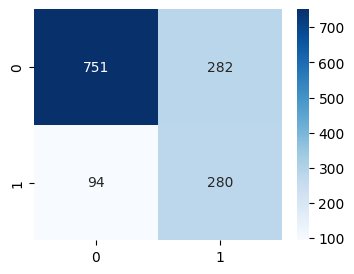

In [56]:
print("GaussianNB Confussion Matrix:")
plt.figure(figsize=(4,3))
sns.heatmap(gnb_confusion, annot=True, fmt='g', cmap='Blues')
plt.show()

# Logistic Regression

In [59]:
logi_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=500))
])

log_param_grid = {
    'model__C': [0.01, 0.05, 0.1, 0.5, 1],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': [None, 'balanced']
}
logistic_grid = GridSearchCV(
    estimator=logi_pipeline,
    param_grid=log_param_grid,
    cv= 5, 
    scoring='recall',
    n_jobs=-1
)
logistic_model = logistic_grid.fit(scale_xtrain, ytrain)

In [77]:
logistic_xtrain_pred = gnb_model.predict(scale_xtrain)
logistic_model_pred = logistic_model.predict(scale_xtest)
logistic_model_pred_proba = logistic_model.predict_proba(scale_xtest)[:, 1]

logistic_train_f1 = recall_score(ytrain, logistic_xtrain_pred)
logistic_test_f1 = recall_score(ytest, logistic_model_pred)

logistic_accuracy = accuracy_score(ytest, logistic_model_pred)
logistic_recall = recall_score(ytest, logistic_model_pred)
logistic_precision = precision_score(ytest, logistic_model_pred)
logistic_f1 = f1_score(ytest, logistic_model_pred)
logistic_confussion = confusion_matrix(ytest, logistic_model_pred)
logistic_roc_auc = roc_auc_score(ytest, logistic_model_pred_proba)

logistic_best_params = logistic_model.best_params_
logistic_best_score = logistic_model.best_score_

logistic_result = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Train recall': logistic_train_f1,
    'Test recall': logistic_test_f1,
    'Accuracy': logistic_accuracy,
    'Recall': logistic_recall,
    'Precision Score': logistic_precision,
    'F1 Score': logistic_f1,
    'Confusion Matrix': logistic_confussion,
    'Roc Auc Score': logistic_roc_auc,
    'Best Params': str(logistic_best_params),
    'Best CV Score': logistic_best_score
}])
logistic_result

,Model,Train recall,Test recall,Accuracy,Recall,Precision Score,F1 Score,Confusion Matrix,Roc Auc Score,Best Params,Best CV Score
0,Logistic Regression,0.754515,0.780749,0.735608,0.780749,0.501718,0.610879,"[[743, 290], [82, 292]]",0.827987,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.796656


Logistic Regression Confussion Matrix:


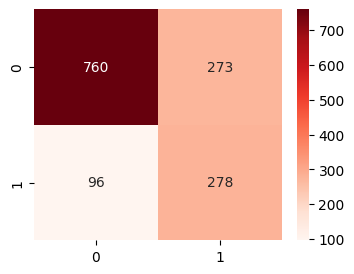

In [30]:
print("Logistic Regression Confussion Matrix:")
plt.figure(figsize=(4,3))
sns.heatmap(logistic_confussion, annot=True, fmt='g', cmap='Reds')
plt.show()

# Random Forest Classifier

In [ ]:
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':[1, 2], 
    'model__max_features': ['sqrt'],
    'model__class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    estimator= rf_pipeline,
    param_grid=rf_param_grid,
    cv = 5, 
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
rf_model = rf_grid.fit(scale_xtrain, ytrain)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
rf_train_pred = rf_model.predict(scale_xtrain)
rf_pred = rf_model.predict(scale_xtest)
rf_pred_proba = rf_model.predict_proba(scale_xtest)[:, 1]

rf_train_f1 = recall_score(ytrain, rf_train_pred)
rf_test_f1 = recall_score(ytest, rf_pred)

rf_accuracy = accuracy_score(ytest, rf_pred)
rf_recall = recall_score(ytest, rf_pred)
rf_precision = precision_score(ytest, rf_pred)
rf_f1 = f1_score(ytest, rf_pred)
rf_confussion = confusion_matrix(ytest, rf_pred)
rf_roc_auc = roc_auc_score(ytest, rf_pred_proba)

rf_best_param = rf_model.best_params_
rf_best_score = rf_model.best_score_

rf_result = pd.DataFrame([{
    'Model': 'Random Forest Classifier',
    'Train recall': rf_train_f1,
    'Test recall': rf_test_f1,
    'Accuracy': rf_accuracy,
    'Recall': rf_recall,
    'Precision Score': rf_precision,
    'F1 Score': rf_f1,
    'Confusion Matrix': rf_confussion,
    'Roc Auc Score': rf_roc_auc,
    'Best Params': str(rf_best_param),
    'Best CV Score': rf_best_score
}])
rf_result

,Model,Train recall,Test recall,Accuracy,Recall,Precision Score,F1 Score,Confusion Matrix,Roc Auc Score,Best Params,Best CV Score
0,Random Forest Classifier,0.754978,0.62486,0.761905,0.745989,0.537572,0.62486,"[[793, 240], [95, 279]]",0.830179,"{'model__class_weight': None, 'model__max_dept...",0.625245


Random Forest Classifier Confussion Matrix:


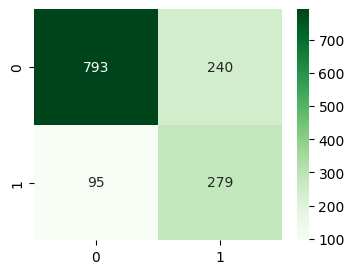

In [ ]:
print("Random Forest Classifier Confussion Matrix:")
plt.figure(figsize=(4,3))
sns.heatmap(rf_confussion, annot=True, fmt='g', cmap='Greens')
plt.show()

# XGBclassifier

In [62]:
xgb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__gamma': [0, 0.1, 0.3],
    'model__child_weight': [1, 3, 5]
}

xgb_gird = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring='recall',
    cv = 5,
    n_jobs=-1,
    verbose=1
)

xgb_model = xgb_gird.fit(scale_xtrain, ytrain)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


In [79]:
xgb_train_pred = xgb_model.predict(scale_xtrain)
xgb_pred = xgb_model.predict(scale_xtest)
xgb_pred_proba = xgb_model.predict_proba(scale_xtest)[:, 1]

xgb_train_f1 = recall_score(ytrain, xgb_train_pred)
xgb_test_f1 = recall_score(ytest, xgb_pred)

xgb_accuracy = accuracy_score(ytest, rf_pred)
xgb_recall = recall_score(ytest, rf_pred)
xgb_precision = precision_score(ytest, rf_pred)
xgb_f1 = f1_score(ytest, rf_pred)
xgb_confussion = confusion_matrix(ytest, rf_pred)
xgb_roc_auc = roc_auc_score(ytest, rf_pred_proba)

xgb_best_param = rf_model.best_params_
xgb_best_score = rf_model.best_score_

xgb_result = pd.DataFrame([{
    'Model': 'XGB Classifier',
    'Train recall': xgb_train_f1,
    'Test recall': xgb_test_f1,
    'Accuracy': xgb_accuracy,
    'Recall': xgb_recall,
    'Precision Score': xgb_precision,
    'F1 Score': xgb_f1,
    'Confusion Matrix': xgb_confussion,
    'Roc Auc Score': xgb_roc_auc,
    'Best Params': str(xgb_best_param),
    'Best CV Score': xgb_best_score
}])
xgb_result

,Model,Train recall,Test recall,Accuracy,Recall,Precision Score,F1 Score,Confusion Matrix,Roc Auc Score,Best Params,Best CV Score
0,XGB Classifier,0.827425,0.802139,0.761905,0.745989,0.537572,0.62486,"[[793, 240], [95, 279]]",0.830179,"{'model__class_weight': None, 'model__max_dept...",0.625245


XGB Classifier Confussion Matrix:


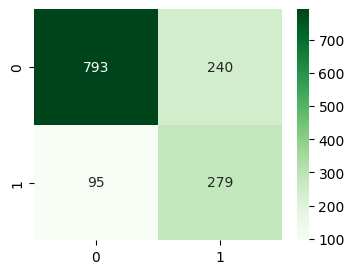

In [81]:
print("XGB Classifier Confussion Matrix:")
plt.figure(figsize=(4,3))
sns.heatmap(xgb_confussion, annot=True, fmt='g', cmap='Greens')
plt.show()

In [80]:
comparing = pd.concat([gnb_result, logistic_result, rf_result, xgb_result], ignore_index=True)
comparing.sort_values(by='Recall', ascending=False)

,Model,Train recall,Test recall,Accuracy,Recall,Precision Score,F1 Score,Confusion Matrix,Roc Auc Score,Best Params,Best CV Score
1,Logistic Regression,0.754515,0.780749,0.735608,0.780749,0.501718,0.610879,"[[743, 290], [82, 292]]",0.827987,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.796656
0,GaussianNB,0.754515,0.748663,0.732765,0.748663,0.498221,0.598291,"[[751, 282], [94, 280]]",0.818240,{'model__var_smoothing': 1e-12},0.751817
2,Random Forest Classifier,0.754978,0.624860,0.761905,0.745989,0.537572,0.624860,"[[793, 240], [95, 279]]",0.830179,"{'model__class_weight': None, 'model__max_dept...",0.625245
3,XGB Classifier,0.827425,0.802139,0.761905,0.745989,0.537572,0.624860,"[[793, 240], [95, 279]]",0.830179,"{'model__class_weight': None, 'model__max_dept...",0.625245


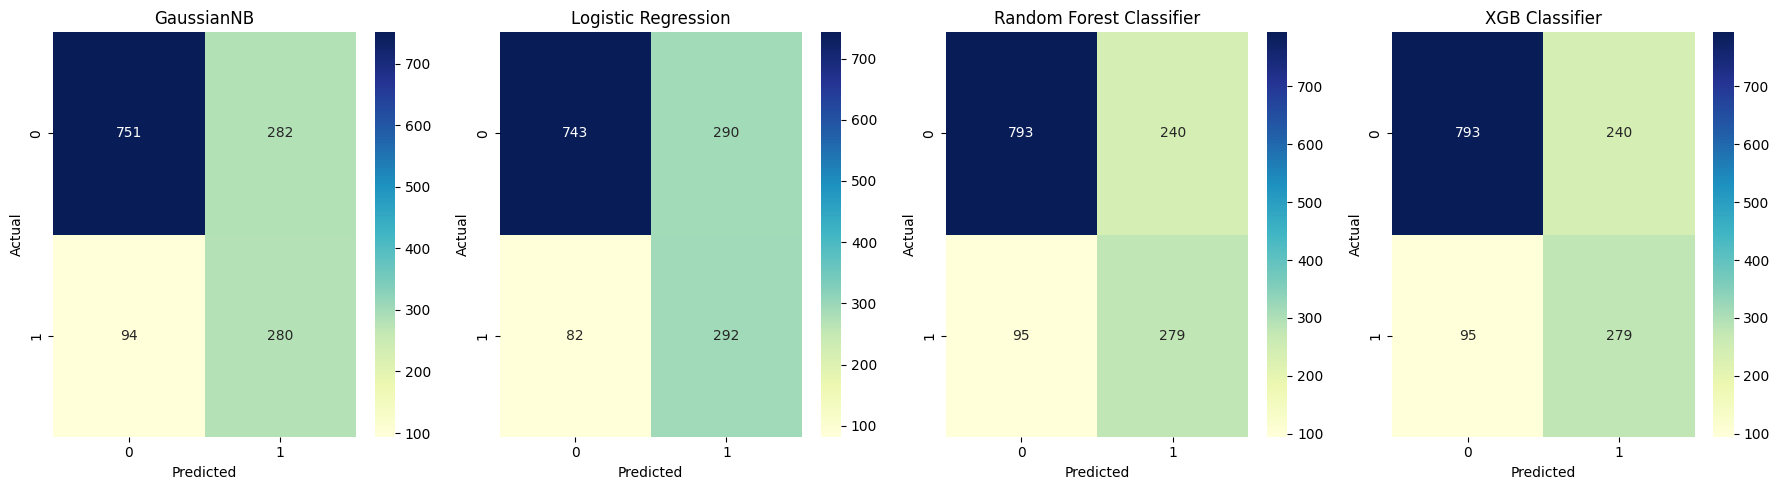

In [84]:
confussion_matrixes = [gnb_confusion, logistic_confussion, rf_confussion, xgb_confussion]
titles = ['GaussianNB', 'Logistic Regression', 'Random Forest Classifier', 'XGB Classifier']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, cm, title in zip(axes, confussion_matrixes, titles):
    sns.heatmap(cm, annot=True, fmt='g', cmap='YlGnBu', ax= ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

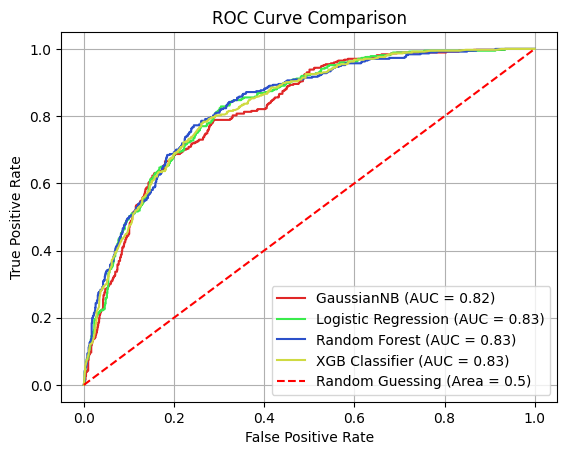

In [88]:
fpr1, tpr1, _ = roc_curve(ytest, gnb_pred_proba)
fpr2, tpr2, _ = roc_curve(ytest, logistic_model_pred_proba)
fpr3, tpr3, _ = roc_curve(ytest, rf_pred_proba)
fpr4, tpr4, _ = roc_curve(ytest, xgb_pred_proba)

plt.plot(fpr1, tpr1, color="#E02727", label= f"GaussianNB (AUC = {gnb_roc_auc:.2f})")
plt.plot(fpr2, tpr2, color="#3AEB4C", label= f"Logistic Regression (AUC = {logistic_roc_auc:.2f})")
plt.plot(fpr3, tpr3, color="#2B50CA", label= f"Random Forest (AUC = {rf_roc_auc:.2f})")
plt.plot(fpr4, tpr4, color="#CFDA42", label= f"XGB Classifier (AUC = {xgb_roc_auc:.2f})")

plt.plot([0, 1], [0, 1], color='red', linestyle="--", label="Random Guessing (Area = 0.5)")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")   
plt.ylabel("True Positive Rate")      
plt.legend(loc='lower right')        
plt.grid(True)                     
plt.show()   

In [27]:
best_rf = rf_model.best_estimator_.named_steps['model']

feature_importance = pd.DataFrame({
    'Feature' : scale_xtrain.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
13,Contract,0.206540
4,tenure,0.142271
16,TotalCharges,0.095960
15,MonthlyCharges,0.090235
17,Average,0.080987
18,InternetService_Fiber optic,0.066877
7,OnlineSecurity,0.048020
10,TechSupport,0.044692
21,PaymentMethod_Electronic check,0.041306
19,InternetService_No,0.035643


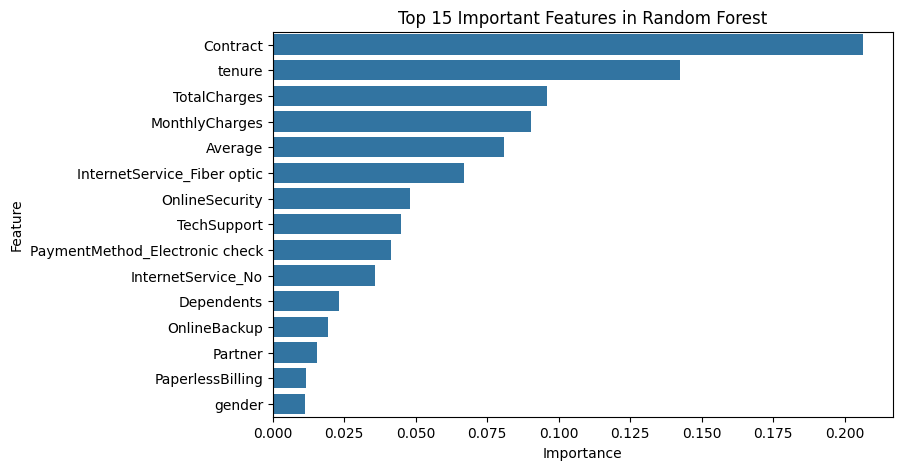

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance.head(15), x='Importance', y= 'Feature')
plt.title("Top 15 Important Features in Random Forest")
plt.show()